# Predictive Modeling and Data Engineering Pipelines for Maternal Health Risk Stratification



**Student Name:** Yabets Desalegn  
**Student ID:** GSE9850/18  
**Course:** Data Management and Engineering  
**Date:** August 24, 2026

## Notebook execution guide

1. Keep this notebook and `Maternal Health Risk Data Set.csv` in the same as this NootBook.
2. Run all cells from top to bottom using a clean kernel.
3. The notebook creates `outputs_final/` with **tables**, **figures**, the **final fitted model**, and **metadata**.
4. The primary model-selection metric is **Macro F1** because all three maternal risk classes are important.

## Data dictionary

| Column | Description |
|---|---|
| Age | Age of the woman in years |
| SystolicBP | Systolic blood pressure in mmHg |
| DiastolicBP | Diastolic blood pressure in mmHg |
| BS | Blood glucose concentration in mmol/L |
| BodyTemp | Body temperature |
| HeartRate | Resting heart rate in beats per minute |
| RiskLevel | Target variable: low risk, mid risk, high risk |

> Academic and clinical notice: this is an educational predictive-modeling project. It is not a clinically validated diagnostic. You can use It as decision-support system with Profesionals gidance.

### Critical Dataset Integrity Statement

This NooteBook uses the corrected original dataset, **Maternal Health Risk Data Set.csv**. The notebook explicitly validates that the source contains **1,014 rows** and all three required target classes: **low risk, mid risk, and high risk**. It will stop rather than silently continue if those conditions are not met.


## Research Questions

**RQ1:** How accurately can machine-learning models classify maternal health observations into low, mid, and high risk?

**RQ2:** Which algorithm generalizes best when selected using stratified cross-validation and Macro F1?

**RQ3:** How does class imbalance affect per-class recall and model interpretation?

**RQ4:** Which maternal health indicators contribute most to the selected model's predictions?

**RQ5:** Do learning curves suggest underfitting, overfitting, or stable generalization?

**RQ6:** What limitations and responsible-use constraints should be considered before applying the model?

## Experimental Design

The workflow is intentionally leakage-safe:

Raw data -> schema validation -> data audit -> feature engineering -> stratified train/test split -> preprocessing inside pipelines -> hyperparameter tuning on the training set only -> untouched holdout evaluation -> interpretation -> final refit on the full dataset -> artifact saving.

The holdout test set is not used for hyperparameter tuning. It is used only after model selection to estimate final generalization performance.

In [1]:
# Optional setup cell for a fresh environment.
# Uncomment the next line only if one of these packages is missing.
# %pip install numpy pandas scipy scikit-learn matplotlib seaborn joblib nbformat nbconvert ipykernel

# Install only missing packages into the current notebook environment.
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas":     "pandas",
    "numpy":      "numpy",
    "matplotlib": "matplotlib",
    "seaborn":    "seaborn",
    "sklearn":    "scikit-learn",
    "joblib":     "joblib",
    "scipy":      "scipy",
}

missing_packages = [
    pkg_name for import_name, pkg_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages, "--quiet"])
else:
    print("All required packages are already installed.")


All required packages are already installed.


In [2]:
from pathlib import Path
import json
import time
import warnings
import platform
import importlib.metadata as importlib_metadata

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import friedmanchisquare

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
N_JOBS = -1
TUNING_SCORING = "f1_macro"

np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "Maternal Health Risk Data Set.csv"
OUTPUT_DIR = PROJECT_DIR / "outputs_final"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MODEL_DIR = OUTPUT_DIR / "models"

for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)
print("Python:", platform.python_version())

Project directory: c:\Users\jabez\OneDrive\Desktop\MSDS\1st Y 3rd Sem\Data Management and Engineering\Assignments and Projects\Aug 31_Project_30%\Yabets_Maternal_Health_Risk_Project
Dataset path: c:\Users\jabez\OneDrive\Desktop\MSDS\1st Y 3rd Sem\Data Management and Engineering\Assignments and Projects\Aug 31_Project_30%\Yabets_Maternal_Health_Risk_Project\Maternal Health Risk Data Set.csv
Output directory: c:\Users\jabez\OneDrive\Desktop\MSDS\1st Y 3rd Sem\Data Management and Engineering\Assignments and Projects\Aug 31_Project_30%\Yabets_Maternal_Health_Risk_Project\outputs_final
Python: 3.14.4


In [3]:
packages_to_report = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "joblib",
]

package_versions = []
for package_name in packages_to_report:
    package_versions.append({
        "Package": package_name,
        "Version": importlib_metadata.version(package_name),
    })

package_versions_df = pd.DataFrame(package_versions)
display(package_versions_df)
package_versions_df.to_csv(TABLE_DIR / "00_package_versions.csv", index=False)

,Package,Version
0,numpy,2.5.2
1,pandas,3.0.5
2,scipy,1.18.1
3,scikit-learn,1.9.0
4,matplotlib,3.11.1
5,seaborn,0.13.2
6,joblib,1.5.3


# Part 1 - Load Corrected Source Dataset

This notebook uses the corrected original Kaggle CSV placed in the `Same` folder. The expected raw dataset has 1,014 rows and all three target classes.

In [4]:
if not DATA_PATH.exists():
    # Fallback: fetch the authoritative dataset directly from the UCI Machine Learning
    # Repository (id=863) instead of requiring a manual Kaggle download. This is the same
    # 1,014-row, 3-class dataset, and also gives a citable DOI for the References section.
    print(f"{DATA_PATH.name} not found locally -- attempting to fetch from the UCI ML Repository (id=863) instead.")
    try:
        from ucimlrepo import fetch_ucirepo
    except ImportError:
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo", "--quiet"])
        from ucimlrepo import fetch_ucirepo

    maternal_health_risk = fetch_ucirepo(id=863)
    raw_df = pd.concat([maternal_health_risk.data.features, maternal_health_risk.data.targets], axis=1)
    raw_df.to_csv(DATA_PATH, index=False)

    print("Fetched from UCI and saved locally as:", DATA_PATH.name)
    print("Citation (IEEE-style, for the References section):")
    print(
        'M. Ahmed, "Maternal Health Risk," UCI Machine Learning Repository, 2020. '
        "[Online]. Available: https://doi.org/10.24432/C5DP5D"
    )
else:
    raw_df = pd.read_csv(DATA_PATH)

raw_df.columns = raw_df.columns.astype(str).str.strip()

print(f"Loaded dataset: {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns")
display(raw_df.head())

Loaded dataset: 1,014 rows and 7 columns


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


# Part 2 - Data Understanding and Quality Audit

The audit verifies the schema, missing values, duplicate measurement patterns, and the full three-class target distribution before modeling.

In [5]:
EXPECTED_COLUMNS = [
    "Age",
    "SystolicBP",
    "DiastolicBP",
    "BS",
    "BodyTemp",
    "HeartRate",
    "RiskLevel",
]

missing_columns = [column for column in EXPECTED_COLUMNS if column not in raw_df.columns]
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

df = raw_df[EXPECTED_COLUMNS].copy()

for column in EXPECTED_COLUMNS:
    if column != "RiskLevel":
        df[column] = pd.to_numeric(df[column], errors="coerce")

TARGET_COLUMN = "RiskLevel"
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str).str.strip().str.lower()

duplicate_count = int(df.duplicated().sum())
missing_summary = df.isna().sum().rename("Missing Values").to_frame()
dtype_summary = df.dtypes.astype(str).rename("Data Type").to_frame()
audit_table = dtype_summary.join(missing_summary)

print("Schema and missing-value audit:")
display(audit_table)
audit_table.to_csv(TABLE_DIR / "01_schema_missing_value_audit.csv")

data_quality_summary = pd.DataFrame([
    {"Check": "Raw rows", "Value": len(df)},
    {"Check": "Raw columns", "Value": df.shape[1]},
    {"Check": "Missing values", "Value": int(df.isna().sum().sum())},
    {"Check": "Exact duplicate measurement rows", "Value": duplicate_count},
])

display(data_quality_summary)
data_quality_summary.to_csv(TABLE_DIR / "02_data_quality_summary.csv", index=False)

Schema and missing-value audit:


,Data Type,Missing Values
Age,int64,0
SystolicBP,int64,0
DiastolicBP,int64,0
BS,float64,0
BodyTemp,float64,0
HeartRate,int64,0
RiskLevel,str,0


,Check,Value
0,Raw rows,1014
1,Raw columns,7
2,Missing values,0
3,Exact duplicate measurement rows,562


An **ordinal-aware** target encoding. The risk levels have a natural order — low < mid < high — so
we deliberately avoid `LabelEncoder`, which assigns codes alphabetically and would break that
ordering.

In [6]:
RISK_ORDER = {
    "low risk": 0,
    "mid risk": 1,
    "high risk": 2,
}

observed_classes = set(df[TARGET_COLUMN].dropna().unique())
unexpected_classes = observed_classes - set(RISK_ORDER.keys())
missing_expected_classes = set(RISK_ORDER.keys()) - observed_classes

if unexpected_classes:
    raise ValueError(f"Unexpected target labels found: {sorted(unexpected_classes)}")
if missing_expected_classes:
    raise ValueError(f"Missing expected target labels: {sorted(missing_expected_classes)}")

class_names = list(RISK_ORDER.keys())
class_labels = [RISK_ORDER[class_name] for class_name in class_names]
class_mapping = {value: key for key, value in RISK_ORDER.items()}

class_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .reindex(class_names)
    .rename_axis("RiskLevel")
    .reset_index(name="Count")
)
class_distribution["Percent"] = class_distribution["Count"] / len(df)

print("Verified three-class target distribution:")
display(class_distribution)
class_distribution.to_csv(TABLE_DIR / "03_target_class_distribution.csv", index=False)

Verified three-class target distribution:


,RiskLevel,Count,Percent
0,low risk,406,0.400394
1,mid risk,336,0.331361
2,high risk,272,0.268245


In [7]:
print("Descriptive statistics for numeric variables:")
descriptive_stats = df.describe().T.round(3)
display(descriptive_stats)
descriptive_stats.to_csv(TABLE_DIR / "04_descriptive_statistics.csv")

Descriptive statistics for numeric variables:


,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.872,13.474,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198,18.404,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.461,13.886,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.726,3.294,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665,1.371,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.302,8.089,7.0,70.0,76.0,80.0,90.0


# Part 3 - Exploratory Data Analysis

The visual audit emphasizes class balance, feature distributions, risk-group differences, and correlation patterns.

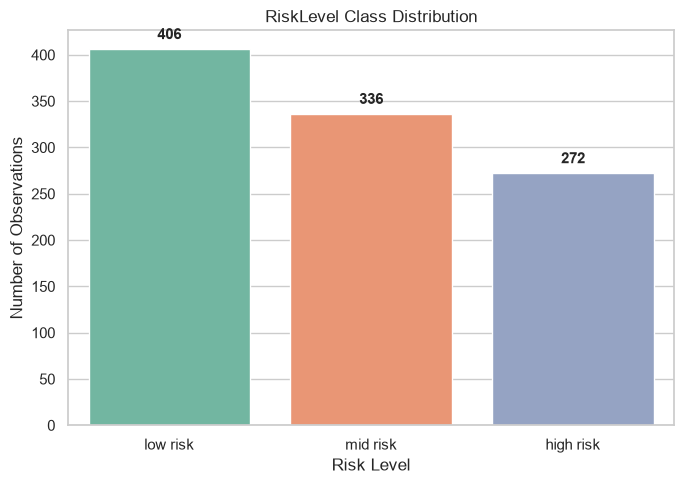

In [8]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=class_distribution,
    x="RiskLevel",
    y="Count",
    order=class_names,
    palette="Set2"
)

plt.title("RiskLevel Class Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Observations")

# Add exact count labels above each bar
for bar, count in zip(ax.patches, class_distribution["Count"]):
    ax.annotate(
        f"{int(count)}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "01_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

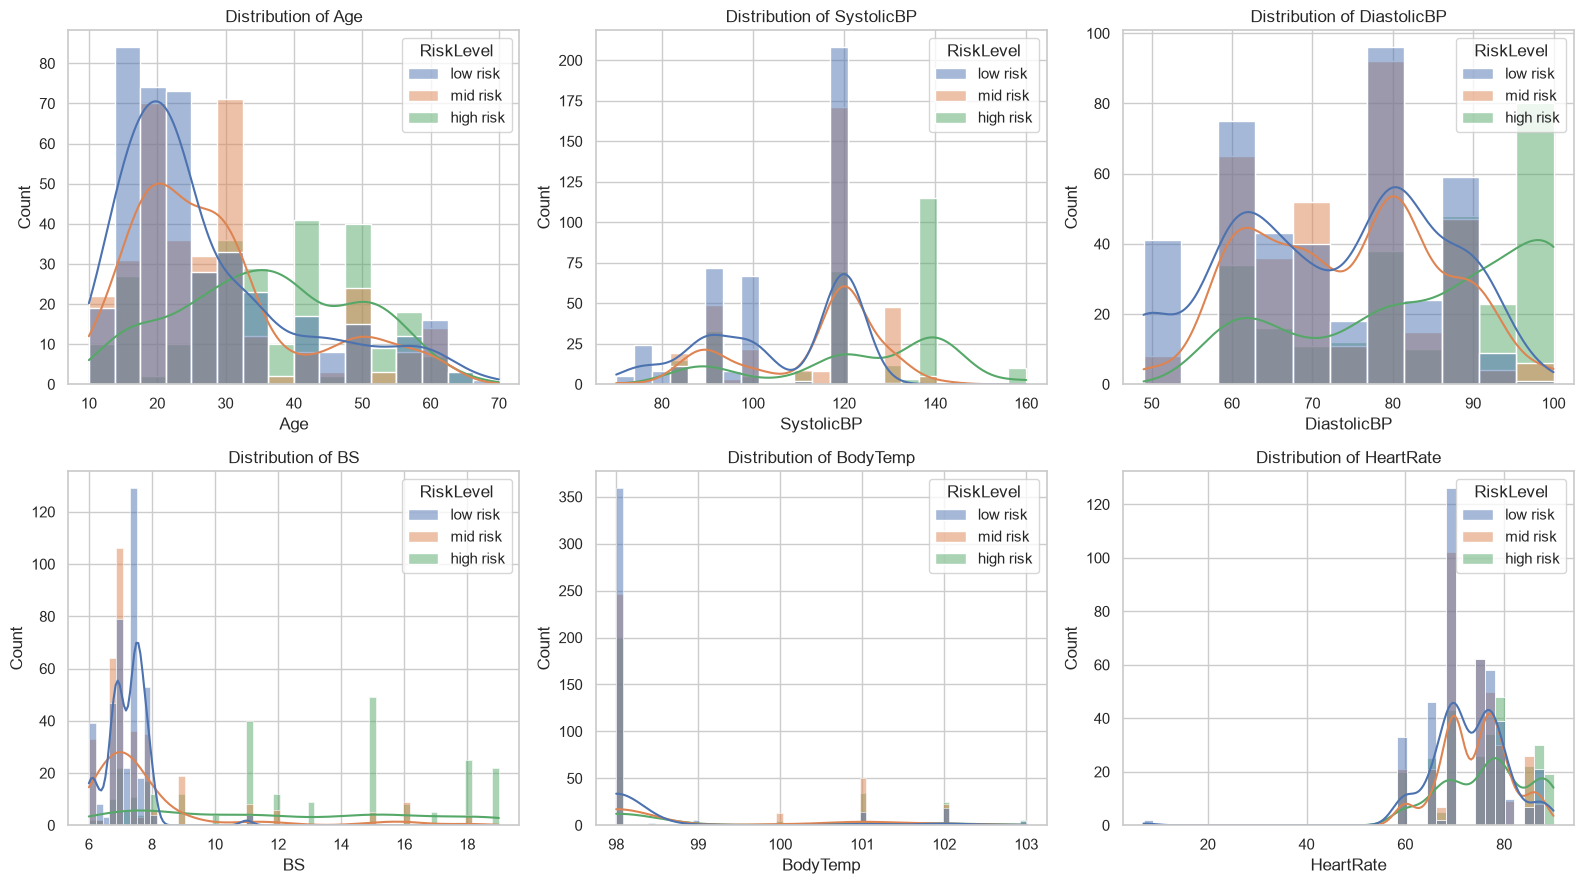

In [9]:
numeric_features = [column for column in df.columns if column != TARGET_COLUMN]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for axis, column in zip(axes, numeric_features):
    sns.histplot(data=df, x=column, hue=TARGET_COLUMN, hue_order=class_names, kde=True, ax=axis)
    axis.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

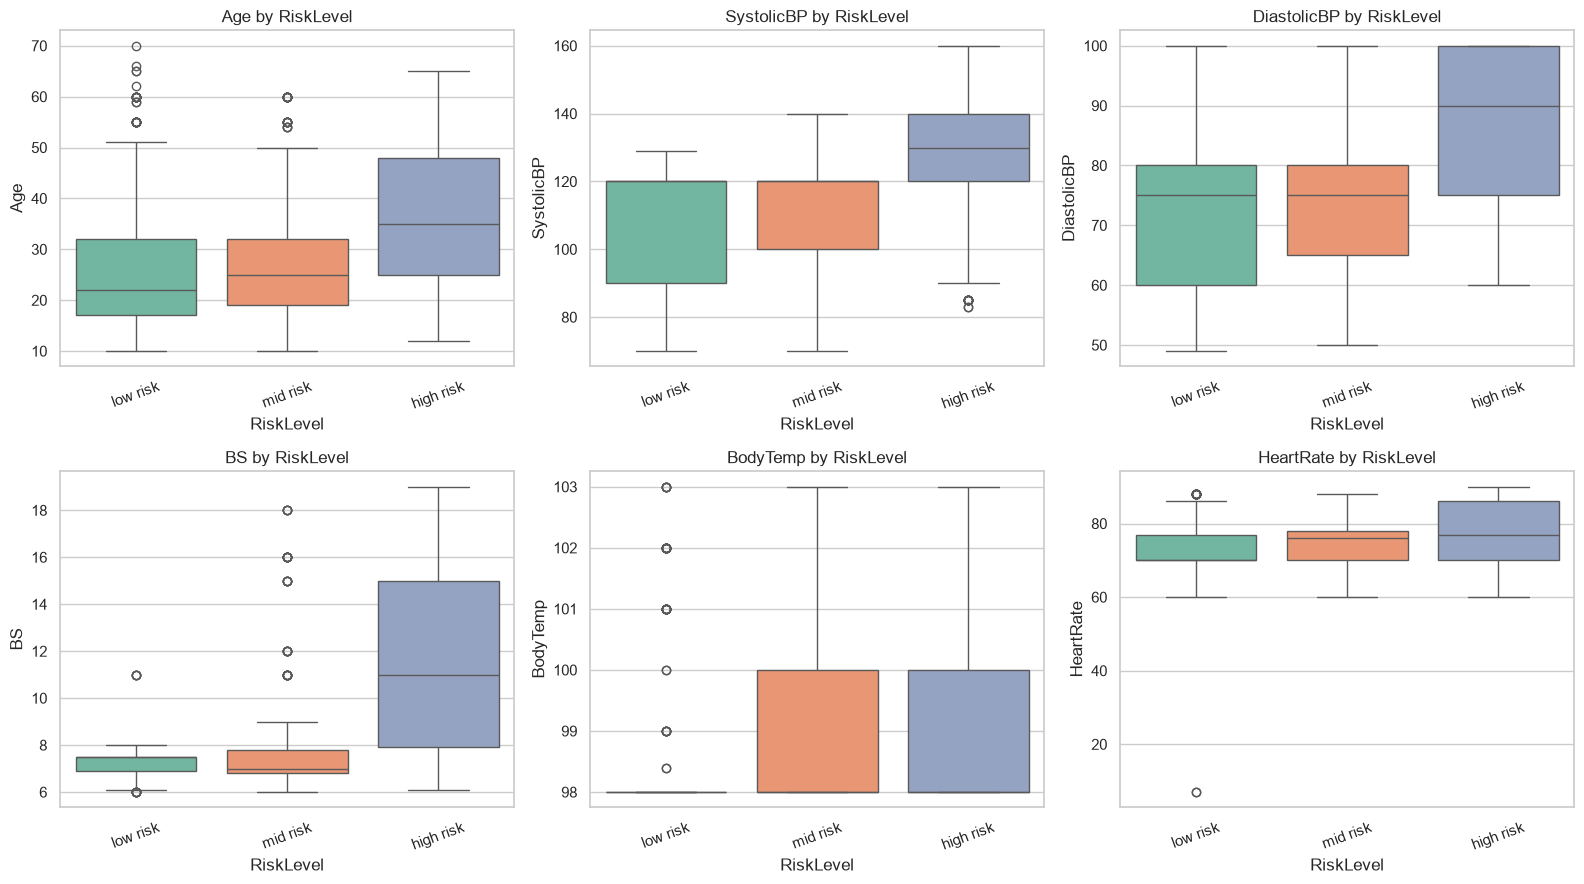

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for axis, column in zip(axes, numeric_features):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=column, order=class_names, ax=axis, palette="Set2")
    axis.set_title(f"{column} by RiskLevel")
    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_boxplots_by_risk.png", dpi=300, bbox_inches="tight")
plt.show()

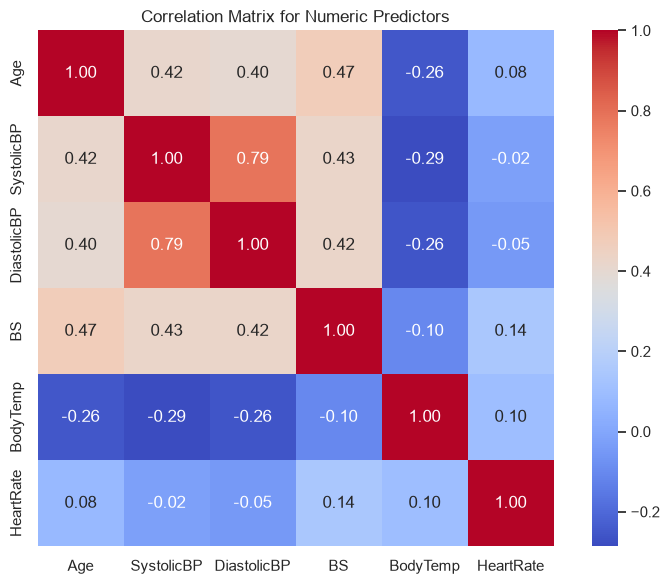

In [11]:
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Numeric Predictors")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

correlation_matrix.to_csv(TABLE_DIR / "05_correlation_matrix.csv")

In [12]:
risk_summary = (
    df.groupby(TARGET_COLUMN)[numeric_features]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
    .reindex(class_names)
)

display(risk_summary)
risk_summary.to_csv(TABLE_DIR / "06_risk_level_summary_statistics.csv")

Age                                SystolicBP                  \
          count    mean median     std min max      count     mean median   
RiskLevel                                                                   
low risk    406  26.869   22.0  13.122  10  70        406  105.867  120.0   
mid risk    336  28.363   25.0  12.553  10  60        336  113.155  120.0   
high risk   272  36.217   35.0  13.032  12  65        272  124.195  130.0   

                   ... BodyTemp                     HeartRate                 \
              std  ...   median    std   min    max     count    mean median   
RiskLevel          ...                                                         
low risk   15.894  ...     98.0  1.109  98.0  103.0       406  72.771   70.0   
mid risk   14.983  ...     98.0  1.434  98.0  103.0       336  74.176   76.0   
high risk  20.227  ...     98.0  1.559  98.0  103.0       272  76.743   77.0   

                          
             std min max  
RiskLevel                 
low risk   8.293   7  88  
mid risk   6.767  60  88  
high risk  8.698  60  90  

[3 rows x 36 columns]

# Part 4 - Data Preparation, Target Encoding and Feature Engineering

Exact duplicate measurement rows are audited but retained in the primary dataset because there is no patient or encounter identifier proving they are erroneous duplicate records. This keeps the analysis aligned with the original 1,014-row dataset while documenting the limitation.

In [13]:
data = df.copy()

data["PulsePressure"] = data["SystolicBP"] - data["DiastolicBP"]
data["MeanArterialPressure"] = data["DiastolicBP"] + (data["PulsePressure"] / 3)
data["SystolicDiastolicRatio"] = np.where(
    data["DiastolicBP"] != 0,
    data["SystolicBP"] / data["DiastolicBP"],
    np.nan,
)

age_bins = [-np.inf, 19, 34, np.inf]
age_labels = ["adolescent", "adult", "advanced_maternal_age"]
data["AgeGroup"] = pd.cut(data["Age"], bins=age_bins, labels=age_labels)
data = pd.get_dummies(data, columns=["AgeGroup"], drop_first=True)

data["RiskLevel_enc"] = data[TARGET_COLUMN].map(RISK_ORDER).astype(int)

feature_names = [column for column in data.columns if column not in [TARGET_COLUMN, "RiskLevel_enc"]]
for column in feature_names:
    if data[column].dtype == bool:
        data[column] = data[column].astype(int)

X = data[feature_names].copy()
y = data["RiskLevel_enc"].copy()

ENGINEERED_FEATURES = [
    "PulsePressure",
    "MeanArterialPressure",
    "SystolicDiastolicRatio",
    "AgeGroup_adult",
    "AgeGroup_advanced_maternal_age",
]

print("Analysis rows retained:", len(data))
print("Feature count:", len(feature_names))
print("Feature set:")
for feature in feature_names:
    print(" -", feature)

feature_schema = pd.DataFrame({"Feature": feature_names})
feature_schema.to_csv(TABLE_DIR / "07_feature_schema.csv", index=False)
display(data.head())

Analysis rows retained: 1014
Feature count: 11
Feature set:
 - Age
 - SystolicBP
 - DiastolicBP
 - BS
 - BodyTemp
 - HeartRate
 - PulsePressure
 - MeanArterialPressure
 - SystolicDiastolicRatio
 - AgeGroup_adult
 - AgeGroup_advanced_maternal_age


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,MeanArterialPressure,SystolicDiastolicRatio,AgeGroup_adult,AgeGroup_advanced_maternal_age,RiskLevel_enc
0,25,130,80,15.0,98.0,86,high risk,50,96.666667,1.625000,1,0,2
1,35,140,90,13.0,98.0,70,high risk,50,106.666667,1.555556,0,1,2
2,29,90,70,8.0,100.0,80,high risk,20,76.666667,1.285714,1,0,2
3,30,140,85,7.0,98.0,70,high risk,55,103.333333,1.647059,1,0,2
4,35,120,60,6.1,98.0,76,low risk,60,80.000000,2.000000,0,1,0


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_distribution = pd.concat(
    [
        y_train.value_counts().reindex(class_labels).rename("Train Count"),
        y_test.value_counts().reindex(class_labels).rename("Test Count"),
    ],
    axis=1,
)
split_distribution.index = [class_mapping[index] for index in split_distribution.index]
split_distribution["Train Percent"] = split_distribution["Train Count"] / len(y_train)
split_distribution["Test Percent"] = split_distribution["Test Count"] / len(y_test)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
display(split_distribution)
split_distribution.to_csv(TABLE_DIR / "08_train_test_class_distribution.csv")

Training shape: (811, 11)
Test shape: (203, 11)


,Train Count,Test Count,Train Percent,Test Percent
low risk,325,81,0.400740,0.399015
mid risk,269,67,0.331689,0.330049
high risk,217,55,0.267571,0.270936


In [15]:
scaled_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

unscaled_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

def safe_model_name(model_name):
    return (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "")
        .replace("(", "")
        .replace(")", "")
    )

def align_probabilities(estimator, X_values):
    raw_probabilities = estimator.predict_proba(X_values)
    estimator_classes = list(getattr(estimator, "classes_", class_labels))
    aligned = np.zeros((len(X_values), len(class_labels)))

    for source_index, class_value in enumerate(estimator_classes):
        if class_value in class_labels:
            target_index = class_labels.index(class_value)
            aligned[:, target_index] = raw_probabilities[:, source_index]

    return aligned

def evaluate_predictions(y_true, y_pred, probabilities=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if probabilities is not None:
        y_binary = label_binarize(y_true, classes=class_labels)
        metrics["ROC-AUC OvR Macro"] = roc_auc_score(
            y_true,
            probabilities,
            labels=class_labels,
            multi_class="ovr",
            average="macro",
        )
        metrics["ROC-AUC OvR Weighted"] = roc_auc_score(
            y_true,
            probabilities,
            labels=class_labels,
            multi_class="ovr",
            average="weighted",
        )
        metrics["Average Precision Macro"] = average_precision_score(
            y_binary,
            probabilities,
            average="macro",
        )

    return metrics

# Part 5 - Logistic Regression Baseline

Logistic Regression provides an interpretable baseline before tuning more flexible models.

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,ROC-AUC OvR Macro,ROC-AUC OvR Weighted,Average Precision Macro
0,Logistic Regression Baseline,0.6502,0.6576,0.6442,0.6576,0.6493,0.6437,0.8171,0.8111,0.6719


Classification report:
              precision    recall  f1-score   support

    low risk       0.68      0.70      0.69        81
    mid risk       0.50      0.43      0.46        67
   high risk       0.75      0.84      0.79        55

    accuracy                           0.65       203
   macro avg       0.64      0.66      0.65       203
weighted avg       0.64      0.65      0.64       203



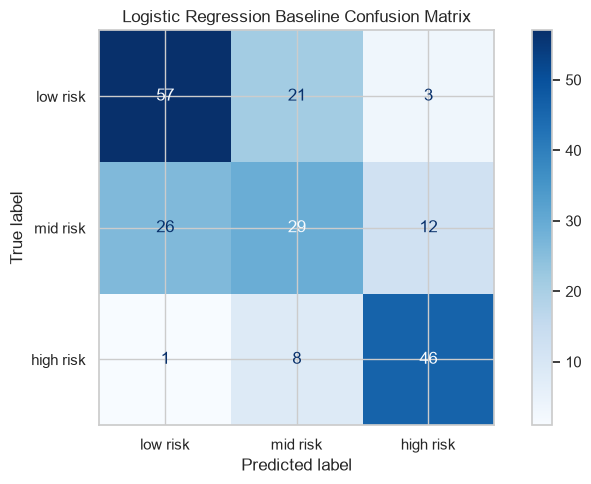

In [16]:
baseline_model = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
])

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_proba = align_probabilities(baseline_model, X_test)
baseline_metrics = evaluate_predictions(y_test, baseline_pred, baseline_proba)

baseline_metrics_df = pd.DataFrame([{"Model": "Logistic Regression Baseline", **baseline_metrics}])
display(baseline_metrics_df.round(4))
baseline_metrics_df.to_csv(TABLE_DIR / "09_logistic_regression_baseline_metrics.csv", index=False)

print("Classification report:")
print(
    classification_report(
        y_test,
        baseline_pred,
        labels=class_labels,
        target_names=class_names,
        zero_division=0,
    )
)

baseline_cm = confusion_matrix(y_test, baseline_pred, labels=class_labels)
ConfusionMatrixDisplay(baseline_cm, display_labels=class_names).plot(cmap="Blues")
plt.title("Logistic Regression Baseline Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_baseline_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Part 6 - Hyperparameter-Tuned Experiments

All seven candidate models are tuned on the training set only using stratified 5-fold cross-validation and Macro F1.

In [17]:
models_and_grids = {
    "Logistic Regression": (
        Pipeline([
            ("preprocessing", scaled_preprocessor),
            ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__class_weight": [None, "balanced"],
        },
    ),
    "Decision Tree": (
        Pipeline([
            ("preprocessing", unscaled_preprocessor),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ]),
        {
            "model__max_depth": [3, 5, 8, None],
            "model__min_samples_leaf": [1, 3, 5],
            "model__class_weight": [None, "balanced"],
        },
    ),
    "KNN": (
        Pipeline([
            ("preprocessing", scaled_preprocessor),
            ("model", KNeighborsClassifier()),
        ]),
        {
            "model__n_neighbors": [3, 5, 7, 11, 15],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    ),
    "SVM": (
        Pipeline([
            ("preprocessing", scaled_preprocessor),
            ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto"],
            "model__class_weight": [None, "balanced"],
        },
    ),
    "Random Forest": (
        Pipeline([
            ("preprocessing", unscaled_preprocessor),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS)),
        ]),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_leaf": [1, 3],
            "model__max_features": ["sqrt", None],
            "model__class_weight": [None, "balanced_subsample"],
        },
    ),
    "Gradient Boosting": (
        Pipeline([
            ("preprocessing", unscaled_preprocessor),
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [1, 2, 3],
            "model__min_samples_leaf": [1, 3],
        },
    ),
    "MLP Neural Network": (
        Pipeline([
            ("preprocessing", scaled_preprocessor),
            ("model", MLPClassifier(
                max_iter=1500,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=30,
                random_state=RANDOM_STATE,
            )),
        ]),
        {
            "model__hidden_layer_sizes": [(64,), (64, 32)],
            "model__activation": ["relu"],
            "model__alpha": [0.0001, 0.001],
            "model__learning_rate_init": [0.0005, 0.001],
        },
    ),
}

print("Models prepared for tuning:")
for model_name, (_, parameter_grid) in models_and_grids.items():
    configuration_count = int(np.prod([len(values) for values in parameter_grid.values()]))
    print(f" - {model_name}: {configuration_count} configurations")

Models prepared for tuning:
 - Logistic Regression: 6 configurations
 - Decision Tree: 24 configurations
 - KNN: 20 configurations
 - SVM: 12 configurations
 - Random Forest: 48 configurations
 - Gradient Boosting: 36 configurations
 - MLP Neural Network: 8 configurations


In [18]:
best_estimators = {}
tuning_details = {}
tuning_records = []

for model_name, (pipeline, parameter_grid) in models_and_grids.items():
    print(f"Tuning {model_name}...")
    start_time = time.time()

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grid,
        scoring=TUNING_SCORING,
        cv=cv,
        n_jobs=N_JOBS,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_train, y_train)

    elapsed_seconds = time.time() - start_time
    best_estimators[model_name] = search.best_estimator_
    tuning_details[model_name] = search

    tuning_records.append({
        "Model": model_name,
        "Best CV Macro F1": search.best_score_,
        "Tuning Time Seconds": elapsed_seconds,
        "Best Parameters": json.dumps(search.best_params_, default=str),
    })

    print(f"  Best CV Macro F1: {search.best_score_:.4f}")
    print(f"  Best parameters: {search.best_params_}")

tuning_results = (
    pd.DataFrame(tuning_records)
    .sort_values("Best CV Macro F1", ascending=False)
    .reset_index(drop=True)
)

display(tuning_results.round(4))
tuning_results.to_csv(TABLE_DIR / "10_hyperparameter_tuning_results.csv", index=False)

Tuning Logistic Regression...
  Best CV Macro F1: 0.6180
  Best parameters: {'model__C': 1, 'model__class_weight': None}
Tuning Decision Tree...
  Best CV Macro F1: 0.8142
  Best parameters: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 1}
Tuning KNN...
  Best CV Macro F1: 0.8057
  Best parameters: {'model__n_neighbors': 15, 'model__p': 1, 'model__weights': 'distance'}
Tuning SVM...
  Best CV Macro F1: 0.6895
  Best parameters: {'model__C': 10, 'model__class_weight': 'balanced', 'model__gamma': 'scale'}
Tuning Random Forest...
  Best CV Macro F1: 0.8348
  Best parameters: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 16, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Tuning Gradient Boosting...
  Best CV Macro F1: 0.8208
  Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Tuning MLP Neural Network...
  Bes

,Model,Best CV Macro F1,Tuning Time Seconds,Best Parameters
0,Random Forest,0.8348,44.1890,"{""model__class_weight"": ""balanced_subsample"", ..."
1,Gradient Boosting,0.8208,13.5021,"{""model__learning_rate"": 0.1, ""model__max_dept..."
2,Decision Tree,0.8142,0.6314,"{""model__class_weight"": ""balanced"", ""model__ma..."
3,KNN,0.8057,0.5585,"{""model__n_neighbors"": 15, ""model__p"": 1, ""mod..."
4,SVM,0.6895,1.4433,"{""model__C"": 10, ""model__class_weight"": ""balan..."
5,MLP Neural Network,0.6585,2.1607,"{""model__activation"": ""relu"", ""model__alpha"": ..."
6,Logistic Regression,0.6180,6.0943,"{""model__C"": 1, ""model__class_weight"": null}"


In [19]:
experiment_records = []

for model_name, search in tuning_details.items():
    cv_results = pd.DataFrame(search.cv_results_)
    best_index = search.best_index_

    experiment_records.append({
        "Model": model_name,
        "Selection Metric": TUNING_SCORING,
        "Best CV Score": float(search.best_score_),
        "Train Score at Best": float(cv_results.loc[best_index, "mean_train_score"]),
        "Validation Score at Best": float(cv_results.loc[best_index, "mean_test_score"]),
        "Validation Std at Best": float(cv_results.loc[best_index, "std_test_score"]),
        "Configurations Evaluated": len(cv_results),
        "Best Parameters": json.dumps(search.best_params_, default=str),
    })

experiment_log_df = (
    pd.DataFrame(experiment_records)
    .sort_values("Best CV Score", ascending=False)
    .reset_index(drop=True)
)

display(experiment_log_df.round(4))
experiment_log_df.to_csv(TABLE_DIR / "11_experiment_tracking.csv", index=False)

experiment_configuration = {
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": CV_FOLDS,
    "selection_metric": TUNING_SCORING,
    "features": feature_names,
    "engineered_features": ENGINEERED_FEATURES,
    "target": TARGET_COLUMN,
    "ordinal_mapping": RISK_ORDER,
    "models": list(models_and_grids.keys()),
    "duplicate_policy": "Exact duplicate measurement rows retained because no patient or encounter identifier is available.",
}

with open(OUTPUT_DIR / "experiment_configuration.json", "w", encoding="utf-8") as file:
    json.dump(experiment_configuration, file, indent=2)

,Model,Selection Metric,Best CV Score,Train Score at Best,Validation Score at Best,Validation Std at Best,Configurations Evaluated,Best Parameters
0,Random Forest,f1_macro,0.8348,0.9353,0.8348,0.0291,48,"{""model__class_weight"": ""balanced_subsample"", ..."
1,Gradient Boosting,f1_macro,0.8208,0.9221,0.8208,0.0288,36,"{""model__learning_rate"": 0.1, ""model__max_dept..."
2,Decision Tree,f1_macro,0.8142,0.9356,0.8142,0.0431,24,"{""model__class_weight"": ""balanced"", ""model__ma..."
3,KNN,f1_macro,0.8057,0.9353,0.8057,0.0186,20,"{""model__n_neighbors"": 15, ""model__p"": 1, ""mod..."
4,SVM,f1_macro,0.6895,0.7763,0.6895,0.0353,12,"{""model__C"": 10, ""model__class_weight"": ""balan..."
5,MLP Neural Network,f1_macro,0.6585,0.6782,0.6585,0.0345,8,"{""model__activation"": ""relu"", ""model__alpha"": ..."
6,Logistic Regression,f1_macro,0.6180,0.6321,0.6180,0.0262,6,"{""model__C"": 1, ""model__class_weight"": null}"


# Part 7 - Untouched Holdout Evaluation

The final model is selected by cross-validation Macro F1. The untouched test set is then used to estimate final performance.

In [20]:
test_predictions = {}
test_probabilities = {}
test_records = []

for model_name, estimator in best_estimators.items():
    predictions = estimator.predict(X_test)
    probabilities = align_probabilities(estimator, X_test)

    test_predictions[model_name] = predictions
    test_probabilities[model_name] = probabilities

    test_records.append({
        "Model": model_name,
        **evaluate_predictions(y_test, predictions, probabilities),
    })

test_results = (
    pd.DataFrame(test_records)
    .sort_values(["F1 Macro", "Balanced Accuracy", "ROC-AUC OvR Macro"], ascending=False)
    .reset_index(drop=True)
)

selected_model_name = tuning_results.iloc[0]["Model"]
selected_model = best_estimators[selected_model_name]
selected_predictions = test_predictions[selected_model_name]
selected_probabilities = test_probabilities[selected_model_name]
selected_test_metrics = test_results[test_results["Model"] == selected_model_name].iloc[0]

display(test_results.round(4))
test_results.to_csv(TABLE_DIR / "12_final_test_set_results.csv", index=False)

print("Model selected by CV Macro F1:", selected_model_name)
print("Selected model test Macro F1:", round(float(selected_test_metrics["F1 Macro"]), 4))

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,ROC-AUC OvR Macro,ROC-AUC OvR Weighted,Average Precision Macro
0,Decision Tree,0.8571,0.8656,0.8581,0.8656,0.8613,0.8563,0.9380,0.9346,0.8792
1,Random Forest,0.8473,0.8574,0.8492,0.8574,0.8524,0.8465,0.9531,0.9508,0.9204
2,KNN,0.8473,0.8565,0.8488,0.8565,0.8521,0.8464,0.9460,0.9431,0.8985
3,Gradient Boosting,0.8227,0.8333,0.8240,0.8333,0.8279,0.8211,0.9364,0.9329,0.8909
4,SVM,0.7685,0.7747,0.7694,0.7747,0.7683,0.7627,0.8772,0.8737,0.7873
5,MLP Neural Network,0.6749,0.6713,0.6792,0.6713,0.6541,0.6494,0.8221,0.8156,0.7048
6,Logistic Regression,0.6552,0.6525,0.6449,0.6525,0.6431,0.6417,0.8165,0.8106,0.6843


Model selected by CV Macro F1: Random Forest
Selected model test Macro F1: 0.8524


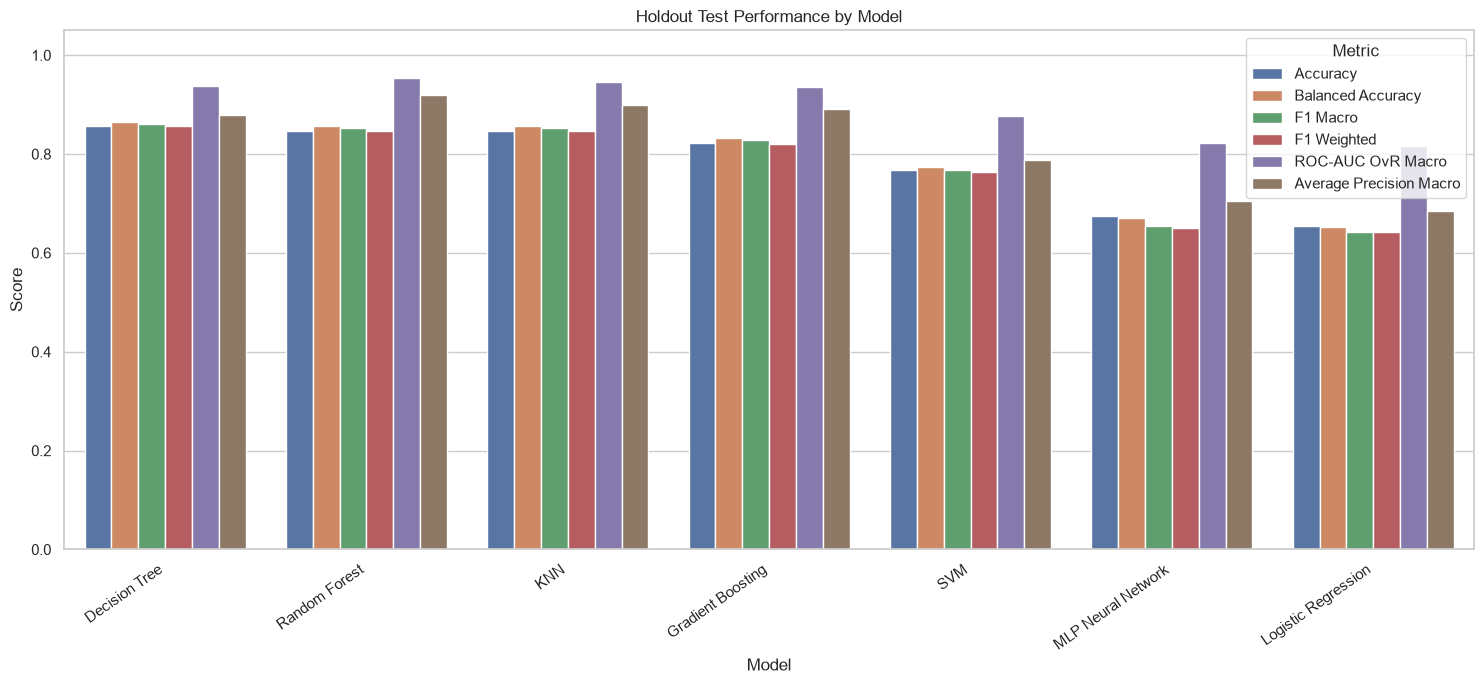

In [21]:
comparison_metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "F1 Macro",
    "F1 Weighted",
    "ROC-AUC OvR Macro",
    "Average Precision Macro",
]

model_comparison_long = test_results.melt(
    id_vars="Model",
    value_vars=comparison_metrics,
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(15, 7))
sns.barplot(data=model_comparison_long, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.title("Holdout Test Performance by Model")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_holdout_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Final classification report for selected model: Random Forest
              precision    recall  f1-score   support

    low risk       0.87      0.80      0.83        81
    mid risk       0.78      0.81      0.79        67
   high risk       0.90      0.96      0.93        55

    accuracy                           0.85       203
   macro avg       0.85      0.86      0.85       203
weighted avg       0.85      0.85      0.85       203



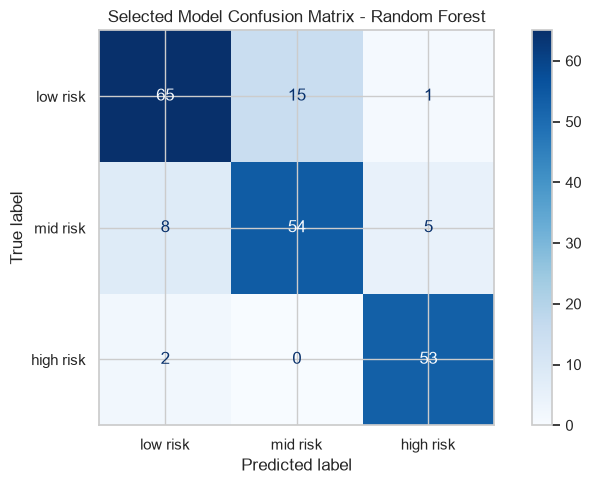

In [22]:
print(f"Final classification report for selected model: {selected_model_name}")
print(
    classification_report(
        y_test,
        selected_predictions,
        labels=class_labels,
        target_names=class_names,
        zero_division=0,
    )
)

selected_cm = confusion_matrix(y_test, selected_predictions, labels=class_labels)
ConfusionMatrixDisplay(selected_cm, display_labels=class_names).plot(cmap="Blues")
plt.title(f"Selected Model Confusion Matrix - {selected_model_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_selected_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

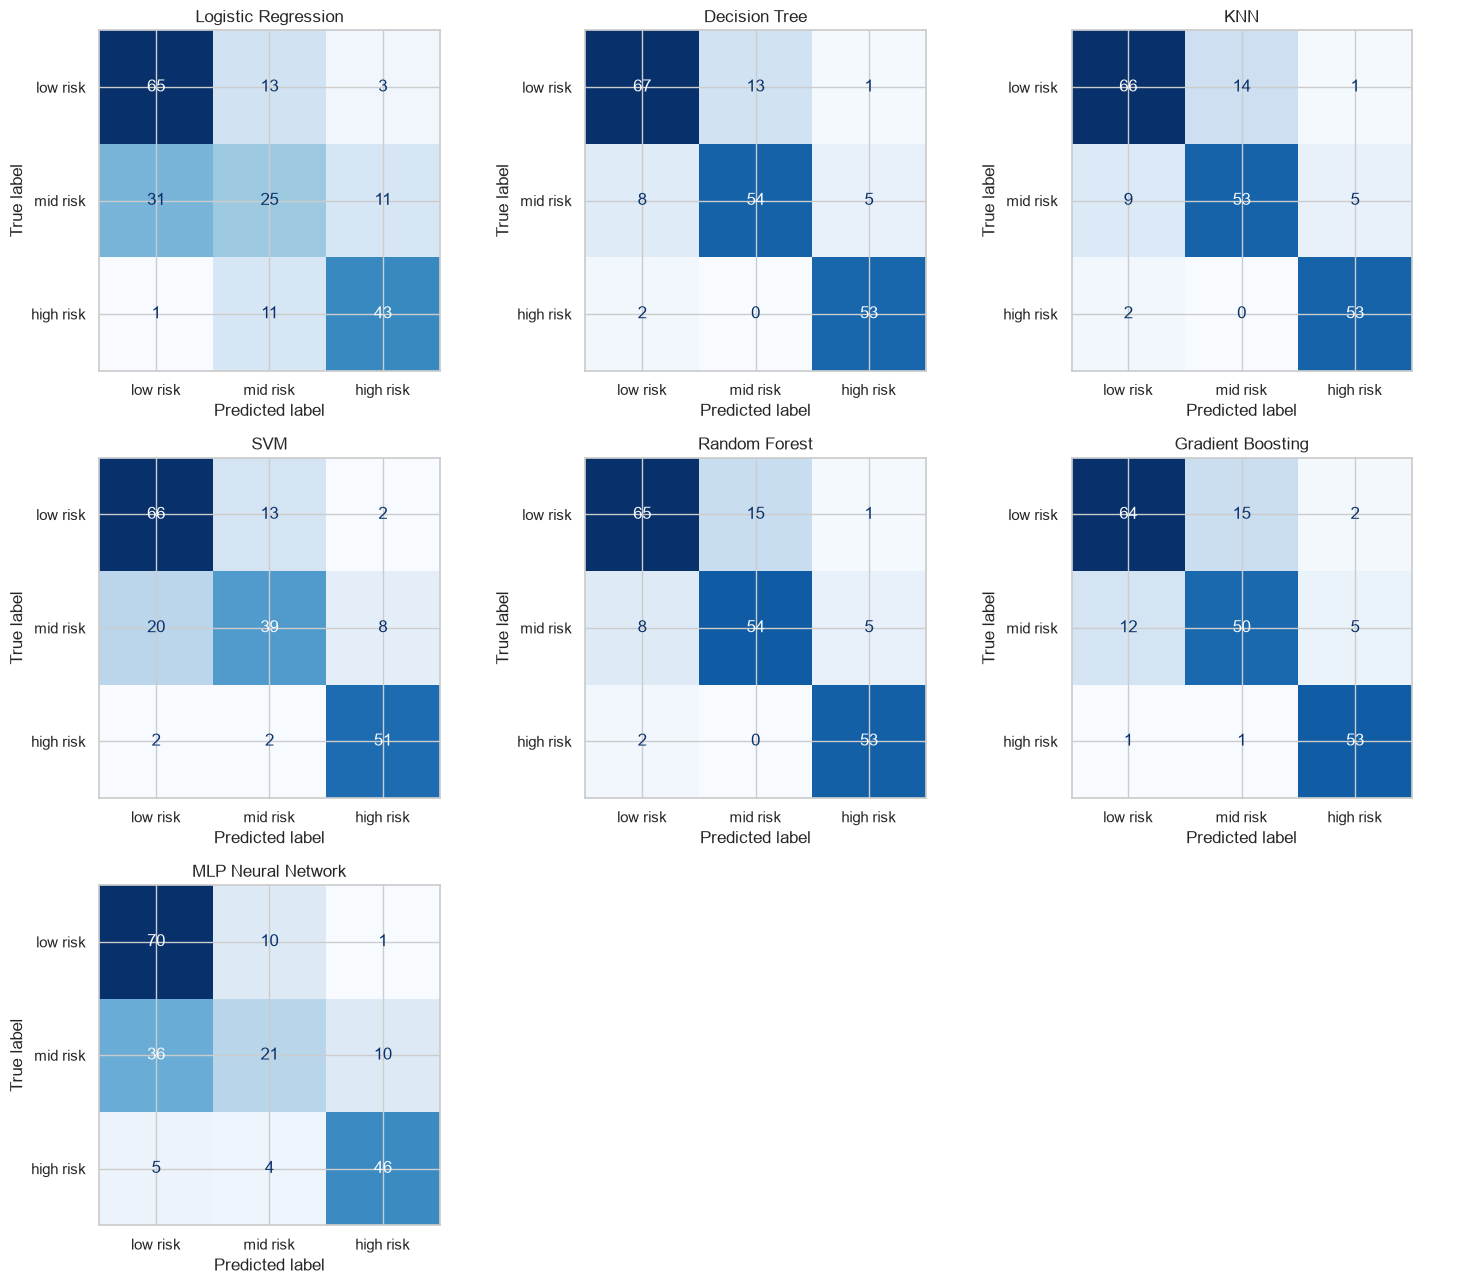

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
axes = axes.flatten()

for axis, (model_name, predictions) in zip(axes, test_predictions.items()):
    matrix = confusion_matrix(y_test, predictions, labels=class_labels)
    ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(
        ax=axis,
        colorbar=False,
        cmap="Blues",
    )
    axis.set_title(model_name)

for axis in axes[len(test_predictions):]:
    axis.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_all_model_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

# Part 8 - Per-Class Performance, ROC Curves and Precision-Recall Curves

Per-class metrics are important because high-risk recall has the most direct public-health relevance.

In [24]:
per_class_rows = []

for model_name, predictions in test_predictions.items():
    report = classification_report(
        y_test,
        predictions,
        labels=class_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    for class_name in class_names:
        row = report[class_name]
        per_class_rows.append({
            "Model": model_name,
            "Class": class_name,
            "Precision": row["precision"],
            "Recall": row["recall"],
            "F1": row["f1-score"],
            "Support": row["support"],
        })

per_class_results = pd.DataFrame(per_class_rows)
display(per_class_results.round(4))
per_class_results.to_csv(TABLE_DIR / "13_per_class_performance.csv", index=False)

,Model,Class,Precision,Recall,F1,Support
0,Logistic Regression,low risk,0.6701,0.8025,0.7303,81.0
1,Logistic Regression,mid risk,0.5102,0.3731,0.4310,67.0
2,Logistic Regression,high risk,0.7544,0.7818,0.7679,55.0
3,Decision Tree,low risk,0.8701,0.8272,0.8481,81.0
4,Decision Tree,mid risk,0.8060,0.8060,0.8060,67.0
5,Decision Tree,high risk,0.8983,0.9636,0.9298,55.0
6,KNN,low risk,0.8571,0.8148,0.8354,81.0
7,KNN,mid risk,0.7910,0.7910,0.7910,67.0
8,KNN,high risk,0.8983,0.9636,0.9298,55.0
9,SVM,low risk,0.7500,0.8148,0.7811,81.0


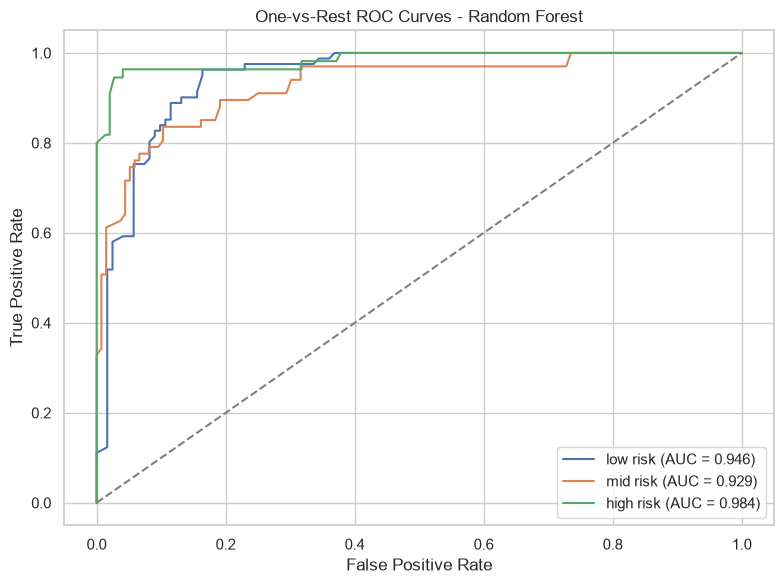

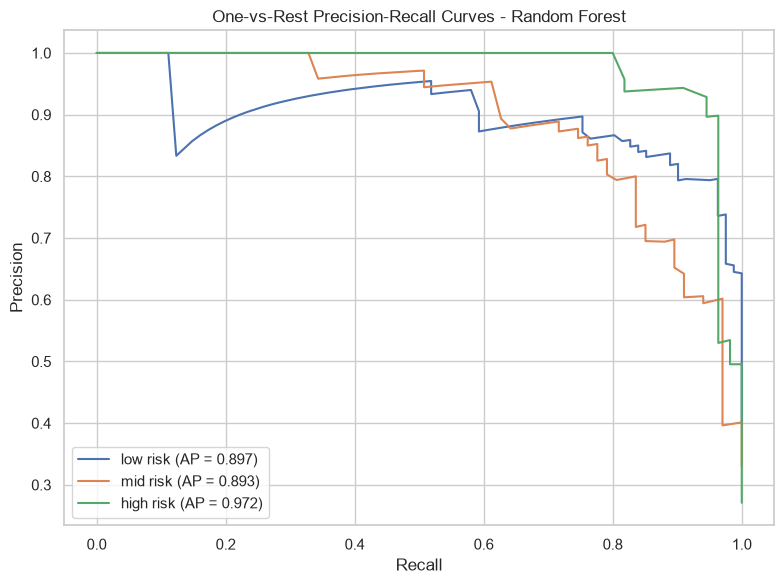

In [25]:
y_test_binary = label_binarize(y_test, classes=class_labels)

plt.figure(figsize=(8, 6))
for class_index, class_name in enumerate(class_names):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binary[:, class_index],
        selected_probabilities[:, class_index],
    )
    class_auc = auc(false_positive_rate, true_positive_rate)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{class_name} (AUC = {class_auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"One-vs-Rest ROC Curves - {selected_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "09_selected_model_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
for class_index, class_name in enumerate(class_names):
    precision_values, recall_values, _ = precision_recall_curve(
        y_test_binary[:, class_index],
        selected_probabilities[:, class_index],
    )
    class_ap = average_precision_score(
        y_test_binary[:, class_index],
        selected_probabilities[:, class_index],
    )
    plt.plot(recall_values, precision_values, label=f"{class_name} (AP = {class_ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"One-vs-Rest Precision-Recall Curves - {selected_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "10_selected_model_precision_recall_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# Part 9 - Learning Curves

Learning curves compare training and validation Macro F1 as the training sample size increases. They help diagnose underfitting, overfitting, and data sufficiency.

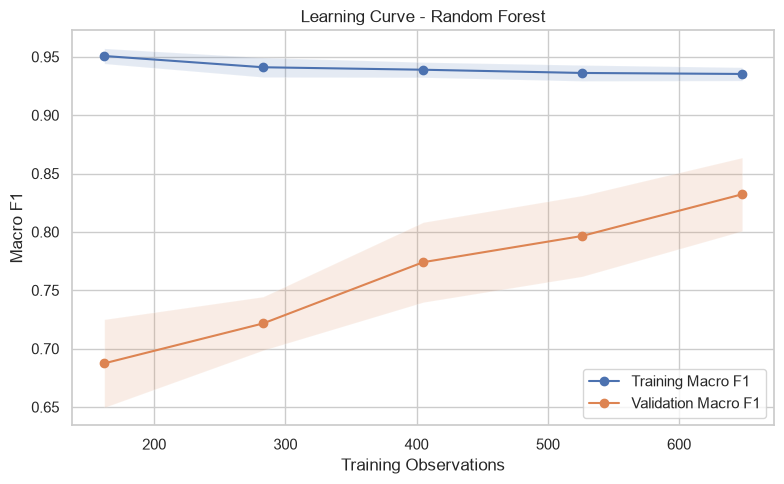

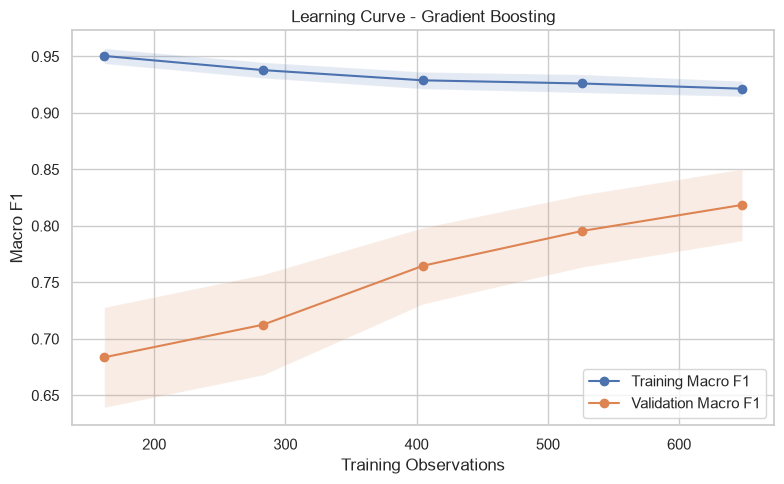

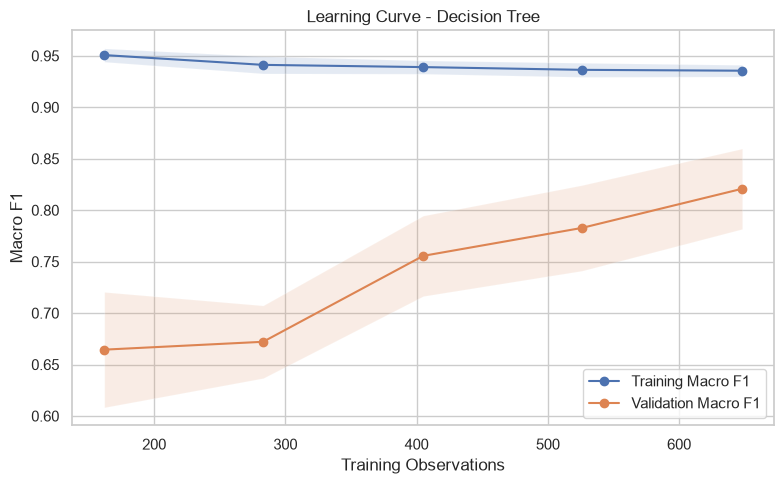

In [26]:
top_models_for_learning = tuning_results["Model"].head(3).tolist()
learning_curve_summary = {}

for model_name in top_models_for_learning:
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=best_estimators[model_name],
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=TUNING_SCORING,
        train_sizes=np.linspace(0.25, 1.0, 5),
        n_jobs=N_JOBS,
    )

    learning_curve_summary[model_name] = {
        "train_sizes": train_sizes.tolist(),
        "train_mean": train_scores.mean(axis=1).tolist(),
        "train_std": train_scores.std(axis=1).tolist(),
        "validation_mean": validation_scores.mean(axis=1).tolist(),
        "validation_std": validation_scores.std(axis=1).tolist(),
    }

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training Macro F1")
    plt.plot(train_sizes, validation_scores.mean(axis=1), marker="o", label="Validation Macro F1")
    plt.fill_between(
        train_sizes,
        train_scores.mean(axis=1) - train_scores.std(axis=1),
        train_scores.mean(axis=1) + train_scores.std(axis=1),
        alpha=0.15,
    )
    plt.fill_between(
        train_sizes,
        validation_scores.mean(axis=1) - validation_scores.std(axis=1),
        validation_scores.mean(axis=1) + validation_scores.std(axis=1),
        alpha=0.15,
    )
    plt.xlabel("Training Observations")
    plt.ylabel("Macro F1")
    plt.title(f"Learning Curve - {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"learning_curve_{safe_model_name(model_name)}.png", dpi=300, bbox_inches="tight")
    plt.show()

with open(TABLE_DIR / "14_learning_curve_results.json", "w", encoding="utf-8") as file:
    json.dump(learning_curve_summary, file, indent=2)

# Part 9b - MLP Neural Network Diagnostics

Inspects the tuned MLP's architecture and training convergence directly -- useful detail for the report's Methodology/Model Development section that the other six models do not need (they have no training curve of their own).


MLP model key: MLP Neural Network
Hidden layer sizes: (64,)
Activation: relu
Solver: adam
Iterations run: 52
Final training loss: 0.6528782204431574


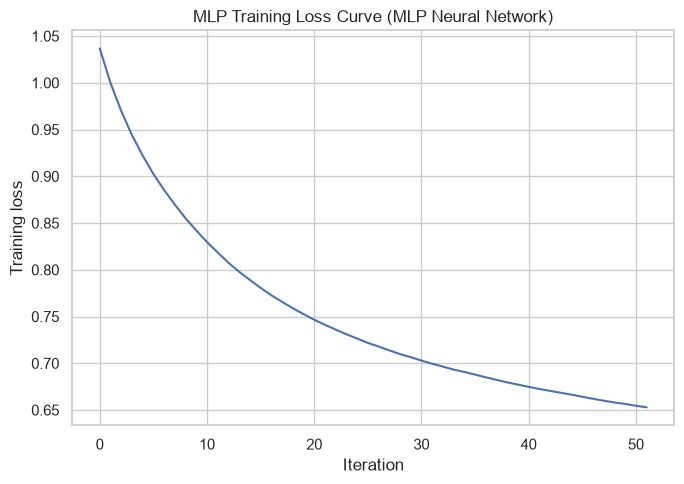

In [27]:
mlp_key = next((name for name in best_estimators if "MLP" in name), None)

if mlp_key is not None:
    mlp_pipeline = best_estimators[mlp_key]
    mlp_estimator = mlp_pipeline.named_steps.get("model", mlp_pipeline.steps[-1][1])

    print("MLP model key:", mlp_key)
    print("Hidden layer sizes:", getattr(mlp_estimator, "hidden_layer_sizes", "n/a"))
    print("Activation:", getattr(mlp_estimator, "activation", "n/a"))
    print("Solver:", getattr(mlp_estimator, "solver", "n/a"))
    print("Iterations run:", getattr(mlp_estimator, "n_iter_", "n/a"))
    print("Final training loss:", getattr(mlp_estimator, "loss_", "n/a"))

    if hasattr(mlp_estimator, "loss_curve_"):
        plt.figure(figsize=(7, 5))
        plt.plot(mlp_estimator.loss_curve_)
        plt.xlabel("Iteration")
        plt.ylabel("Training loss")
        plt.title(f"MLP Training Loss Curve ({mlp_key})")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "09b_mlp_loss_curve.png", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("No loss_curve_ available for this solver configuration.")
else:
    print("No MLP model found among the tuned estimators; skipping MLP diagnostics.")


# Part 10 - Statistical Model Comparison

The Friedman test compares paired cross-validation Macro F1 scores across all tuned models. This is more appropriate than a single pairwise test when comparing multiple algorithms.

In [28]:
cv_score_matrix = {}

for model_name, estimator in best_estimators.items():
    cv_scores_for_model = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=TUNING_SCORING,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    cv_score_matrix[model_name] = cv_scores_for_model["test_score"]

cv_scores_df = pd.DataFrame(cv_score_matrix)
display(cv_scores_df.round(4))
cv_scores_df.to_csv(TABLE_DIR / "15_paired_cv_macro_f1_scores.csv", index=False)

friedman_statistic, friedman_p_value = friedmanchisquare(
    *[cv_scores_df[column].values for column in cv_scores_df.columns]
)

friedman_results = pd.DataFrame([
    {
        "Test": "Friedman",
        "Statistic": friedman_statistic,
        "p_value": friedman_p_value,
        "Interpretation": (
            "Significant at alpha=0.05"
            if friedman_p_value < 0.05
            else "Not significant at alpha=0.05"
        ),
    }
])

display(friedman_results)
friedman_results.to_csv(TABLE_DIR / "16_friedman_model_comparison.csv", index=False)

,Logistic Regression,Decision Tree,KNN,SVM,Random Forest,Gradient Boosting,MLP Neural Network
0,0.5928,0.8851,0.8316,0.7256,0.8736,0.8624,0.7178
1,0.6022,0.7772,0.7787,0.6422,0.7943,0.7852,0.6147
2,0.6612,0.7620,0.7918,0.6697,0.8105,0.7981,0.6420
3,0.5984,0.8238,0.8093,0.6748,0.8390,0.8134,0.6476
4,0.6353,0.8230,0.8170,0.7352,0.8566,0.8447,0.6704


,Test,Statistic,p_value,Interpretation
0,Friedman,27.514286,0.000116,Significant at alpha=0.05


# Part 11 - Model Interpretation with Permutation Importance

Permutation importance is model-agnostic, so it can interpret the selected model even if the selected algorithm does not expose built-in feature importances.

,Feature,Importance Mean,Importance Std
0,BS,0.28121,0.02320
1,SystolicBP,0.06780,0.01233
2,Age,0.04861,0.01333
3,BodyTemp,0.04683,0.00993
4,HeartRate,0.00865,0.01224
5,MeanArterialPressure,0.00678,0.01008
6,AgeGroup_adult,0.00335,0.00381
7,DiastolicBP,-0.00087,0.00467
8,AgeGroup_advanced_maternal_age,-0.00398,0.00422
9,PulsePressure,-0.00737,0.00755


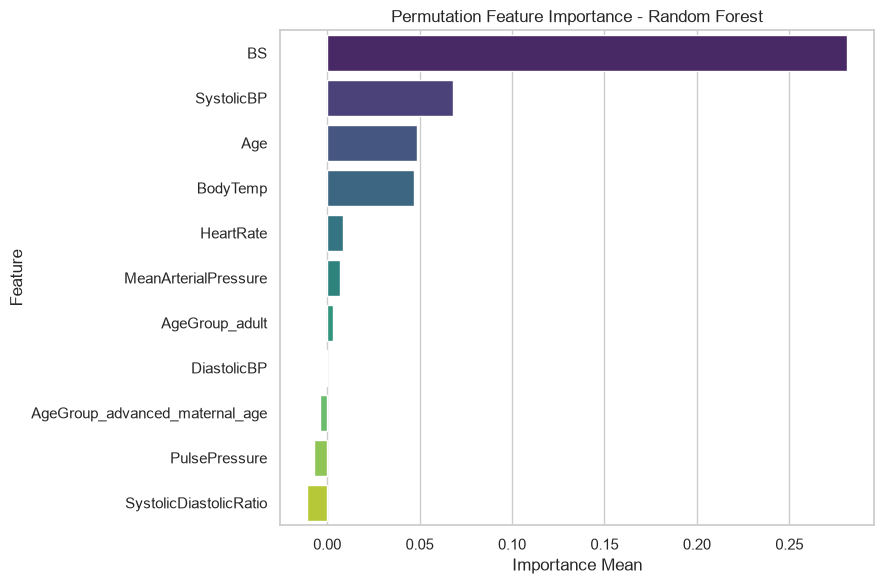

In [29]:
permutation_result = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring=TUNING_SCORING,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)

permutation_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance Mean": permutation_result.importances_mean,
        "Importance Std": permutation_result.importances_std,
    })
    .sort_values("Importance Mean", ascending=False)
    .reset_index(drop=True)
)

display(permutation_importance_df.round(5))
permutation_importance_df.to_csv(TABLE_DIR / "17_permutation_feature_importance.csv", index=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=permutation_importance_df, x="Importance Mean", y="Feature", palette="viridis")
plt.title(f"Permutation Feature Importance - {selected_model_name}")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "11_permutation_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
selected_estimator = selected_model.named_steps["model"]

if hasattr(selected_estimator, "feature_importances_"):
    built_in_importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Built-in Importance": selected_estimator.feature_importances_,
        })
        .sort_values("Built-in Importance", ascending=False)
        .reset_index(drop=True)
    )
    display(built_in_importance_df.round(5))
    built_in_importance_df.to_csv(TABLE_DIR / "18_builtin_feature_importance.csv", index=False)

if isinstance(selected_estimator, DecisionTreeClassifier):
    plt.figure(figsize=(18, 10))
    plot_tree(
        selected_estimator,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        max_depth=3,
        fontsize=9,
    )
    plt.title("Selected Decision Tree Structure, Truncated to Depth 3")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "12_decision_tree_structure.png", dpi=300, bbox_inches="tight")
    plt.show()

,Feature,Built-in Importance
0,BS,0.33730
1,Age,0.11144
2,SystolicBP,0.10833
3,MeanArterialPressure,0.10428
4,HeartRate,0.07329
5,SystolicDiastolicRatio,0.06369
6,DiastolicBP,0.06279
7,PulsePressure,0.05295
8,BodyTemp,0.05213
9,AgeGroup_advanced_maternal_age,0.01809


# Part 12 - Error Analysis

Error analysis identifies where the selected model confuses risk levels and whether incorrect predictions are made with high confidence.

In [31]:
error_analysis = X_test.copy()
error_analysis["Actual"] = y_test.map(class_mapping).values
error_analysis["Predicted"] = pd.Series(selected_predictions, index=X_test.index).map(class_mapping).values
error_analysis["Correct"] = error_analysis["Actual"] == error_analysis["Predicted"]
error_analysis["Prediction Confidence"] = selected_probabilities.max(axis=1)

misclassified_cases = error_analysis[~error_analysis["Correct"]].copy()

print("Test observations:", len(error_analysis))
print("Correct predictions:", int(error_analysis["Correct"].sum()))
print("Misclassified observations:", len(misclassified_cases))
print("Test error rate:", round(len(misclassified_cases) / len(error_analysis), 4))

display(misclassified_cases.sort_values("Prediction Confidence").head(25))
misclassified_cases.to_csv(TABLE_DIR / "19_selected_model_misclassified_cases.csv", index=False)

error_transition_matrix = (
    pd.crosstab(error_analysis["Actual"], error_analysis["Predicted"])
    .reindex(index=class_names, columns=class_names, fill_value=0)
)

display(error_transition_matrix)
error_transition_matrix.to_csv(TABLE_DIR / "20_error_transition_matrix.csv")

Test observations: 203
Correct predictions: 172
Misclassified observations: 31
Test error rate: 0.1527


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,PulsePressure,MeanArterialPressure,SystolicDiastolicRatio,AgeGroup_adult,AgeGroup_advanced_maternal_age,Actual,Predicted,Correct,Prediction Confidence
280,60,120,80,7.7,98.0,75,40,93.333333,1.500000,0,1,low risk,mid risk,False,0.390511
563,17,90,65,7.5,103.0,67,25,73.333333,1.384615,0,0,low risk,mid risk,False,0.450463
340,55,120,80,6.9,102.0,80,40,93.333333,1.500000,0,1,low risk,mid risk,False,0.517805
323,60,120,80,6.9,98.0,76,40,93.333333,1.500000,0,1,low risk,mid risk,False,0.555738
412,55,120,90,6.8,98.0,78,30,100.000000,1.333333,0,1,low risk,mid risk,False,0.590966
372,60,120,85,15.0,98.0,60,35,96.666667,1.411765,0,1,mid risk,high risk,False,0.609432
818,60,120,85,15.0,98.0,60,35,96.666667,1.411765,0,1,mid risk,high risk,False,0.609432
545,23,100,85,7.5,98.0,66,15,90.000000,1.176471,1,0,low risk,mid risk,False,0.617590
556,60,120,80,7.5,98.0,75,40,93.333333,1.500000,0,1,low risk,mid risk,False,0.637661
500,48,120,80,11.0,98.0,88,40,93.333333,1.500000,0,1,mid risk,high risk,False,0.641537


Predicted,low risk,mid risk,high risk
Actual,,,
low risk,65,15,1
mid risk,8,54,5
high risk,2,0,53


# Part 13 - Descriptive Unsupervised Check

PCA and K-Means are not used for supervised prediction. They provide a descriptive check of whether risk classes form visible structure in the engineered feature space.

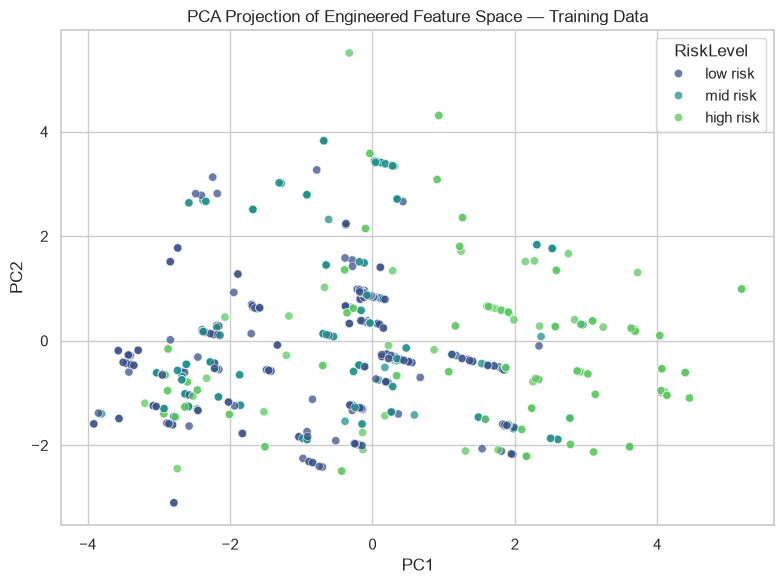

Cluster,0,1,2
RiskLevel,,,
low risk,119,136,70
mid risk,66,147,56
high risk,42,58,117


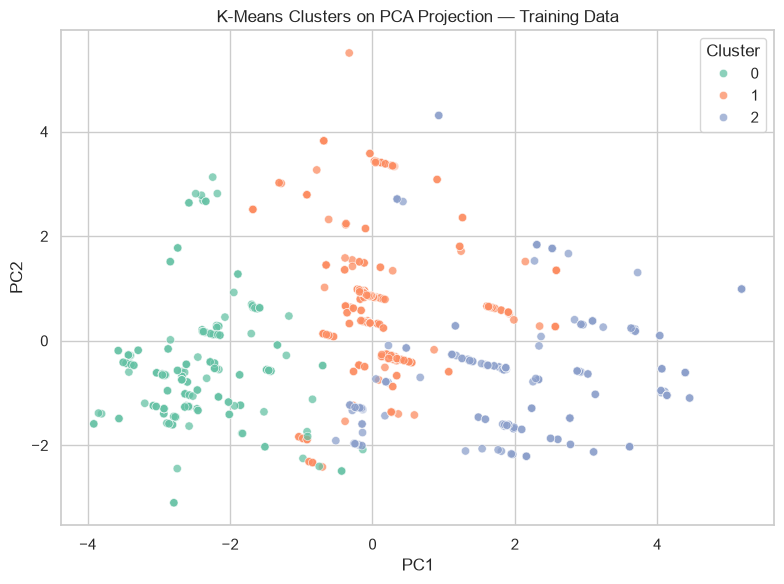

In [32]:
# ============================================================
# Part 13 — PCA Projection and K-Means Clustering
# ============================================================

pca_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
])

# Fit PCA only on the training data
pca_coordinates = pca_pipeline.fit_transform(X_train)

# Build PCA dataframe
pca_df = pd.DataFrame(
    pca_coordinates,
    columns=["PC1", "PC2"]
)

# Add corresponding training-set target labels
pca_df["RiskLevel"] = (
    y_train.reset_index(drop=True)
    .map(class_mapping)
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="RiskLevel",
    hue_order=class_names,
    palette="viridis",
    alpha=0.75
)

plt.title("PCA Projection of Engineered Feature Space — Training Data")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "13_pca_projection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# K-Means Clustering
# ============================================================

clustering_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=3,
        random_state=RANDOM_STATE,
        n_init=10
    )),
])

# Fit K-Means only on the training data
cluster_labels = clustering_pipeline.fit_predict(X_train)

pca_df["Cluster"] = cluster_labels

cluster_crosstab = pd.crosstab(
    pca_df["RiskLevel"],
    pca_df["Cluster"]
).reindex(
    index=class_names,
    fill_value=0
)

display(cluster_crosstab)

cluster_crosstab.to_csv(
    TABLE_DIR / "21_kmeans_vs_true_label_crosstab.csv"
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.75
)

plt.title("K-Means Clusters on PCA Projection — Training Data")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "14_kmeans_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Part 14 - Final Refit and Artifact Saving

After model selection and holdout evaluation are complete, the selected model is refit on the full 1,014-row dataset for the saved deployment/demo artifact. It is standard
practice to refit it on **all** available data (train + test) before saving, so the deployed
model benefits from every observation. All reported metrics above still come from the honest,
untouched test-set evaluation -- this refit happens only after that evaluation is complete.

In [33]:
final_model = clone(selected_model)
final_model.fit(X, y)

model_path = MODEL_DIR / "maternal_risk_final_model.joblib"
joblib.dump(final_model, model_path)

final_metadata = {
    "project_title": "Predictive Modeling and Data Engineering Pipelines for Maternal Health Risk Stratification",
    "dataset": DATA_PATH.name,
    "raw_rows": int(len(raw_df)),
    "analysis_rows": int(len(data)),
    "target": TARGET_COLUMN,
    "classes": class_names,
    "ordinal_mapping": RISK_ORDER,
    "features": feature_names,
    "engineered_features": ENGINEERED_FEATURES,
    "selected_model": selected_model_name,
    "selection_metric": TUNING_SCORING,
    "selected_model_best_cv_macro_f1": float(tuning_results.iloc[0]["Best CV Macro F1"]),
    "selected_model_test_metrics": {
        key: float(value)
        for key, value in selected_test_metrics.items()
        if key != "Model"
    },
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "cv_folds": CV_FOLDS,
    "duplicate_measurement_rows_retained": duplicate_count,
}

with open(MODEL_DIR / "model_metadata.json", "w", encoding="utf-8") as file:
    json.dump(final_metadata, file, indent=2)

final_summary = pd.DataFrame([
    {
        "Selected Model": selected_model_name,
        "Selection Metric": TUNING_SCORING,
        "Best CV Macro F1": tuning_results.iloc[0]["Best CV Macro F1"],
        "Test Accuracy": selected_test_metrics["Accuracy"],
        "Test Balanced Accuracy": selected_test_metrics["Balanced Accuracy"],
        "Test Macro F1": selected_test_metrics["F1 Macro"],
        "Test ROC-AUC OvR Macro": selected_test_metrics["ROC-AUC OvR Macro"],
        "Test Average Precision Macro": selected_test_metrics["Average Precision Macro"],
        "Raw Rows": len(raw_df),
        "Analysis Rows": len(data),
    }
])

display(final_summary.round(4))
final_summary.to_csv(TABLE_DIR / "22_final_experiment_summary.csv", index=False)

print("Saved final model:", model_path)
print("Saved metadata:", MODEL_DIR / "model_metadata.json")

,Selected Model,Selection Metric,Best CV Macro F1,Test Accuracy,Test Balanced Accuracy,Test Macro F1,Test ROC-AUC OvR Macro,Test Average Precision Macro,Raw Rows,Analysis Rows
0,Random Forest,f1_macro,0.8348,0.8473,0.8574,0.8524,0.9531,0.9204,1014,1014


Saved final model: c:\Users\jabez\OneDrive\Desktop\MSDS\1st Y 3rd Sem\Data Management and Engineering\Assignments and Projects\Aug 31_Project_30%\Yabets_Maternal_Health_Risk_Project\outputs_final\models\maternal_risk_final_model.joblib
Saved metadata: c:\Users\jabez\OneDrive\Desktop\MSDS\1st Y 3rd Sem\Data Management and Engineering\Assignments and Projects\Aug 31_Project_30%\Yabets_Maternal_Health_Risk_Project\outputs_final\models\model_metadata.json


# Part 15 - Demonstration ( Adaptive Live Prediction )

This function can be used to demonstrate prediction on a new observation. It rebuilds engineered features in the same order as the training pipeline.

In [34]:
def build_prediction_row(age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate):
    pulse_pressure = systolic_bp - diastolic_bp
    mean_arterial_pressure = diastolic_bp + (pulse_pressure / 3)
    systolic_diastolic_ratio = systolic_bp / diastolic_bp if diastolic_bp != 0 else np.nan

    if age < 20:
        age_group = "adolescent"
    elif age <= 34:
        age_group = "adult"
    else:
        age_group = "advanced_maternal_age"

    row = {
        "Age": age,
        "SystolicBP": systolic_bp,
        "DiastolicBP": diastolic_bp,
        "BS": blood_sugar,
        "BodyTemp": body_temp,
        "HeartRate": heart_rate,
        "PulsePressure": pulse_pressure,
        "MeanArterialPressure": mean_arterial_pressure,
        "SystolicDiastolicRatio": systolic_diastolic_ratio,
    }

    for feature in feature_names:
        if feature.startswith("AgeGroup_"):
            row[feature] = 1 if feature == f"AgeGroup_{age_group}" else 0

    prediction_row = pd.DataFrame([row])
    for feature in feature_names:
        if feature not in prediction_row.columns:
            prediction_row[feature] = 0

    return prediction_row[feature_names]

def predict_maternal_risk(age, systolic_bp, diastolic_bp, blood_sugar, body_temp, heart_rate):
    prediction_row = build_prediction_row(
        age=age,
        systolic_bp=systolic_bp,
        diastolic_bp=diastolic_bp,
        blood_sugar=blood_sugar,
        body_temp=body_temp,
        heart_rate=heart_rate,
    )

    encoded_prediction = int(final_model.predict(prediction_row)[0])
    predicted_label = class_mapping[encoded_prediction]

    result = {
        "Predicted Risk Level": predicted_label,
        "Model": selected_model_name,
    }

    if hasattr(final_model, "predict_proba"):
        probabilities = align_probabilities(final_model, prediction_row)[0]
        result["Probabilities"] = (
            pd.DataFrame({
                "Risk Level": class_names,
                "Probability": probabilities,
            })
            .sort_values("Probability", ascending=False)
            .reset_index(drop=True)
        )

    return result

demo_prediction = predict_maternal_risk(
    age=35,
    systolic_bp=140,
    diastolic_bp=95,
    blood_sugar=8.5,
    body_temp=98.6,
    heart_rate=88,
)

print("Predicted Risk Level:", demo_prediction["Predicted Risk Level"])
print("Model:", demo_prediction["Model"])
display(demo_prediction["Probabilities"])

Predicted Risk Level: high risk
Model: Random Forest


,Risk Level,Probability
0,high risk,0.946808
1,mid risk,0.033621
2,low risk,0.019571


# Part 16 - Limitations and Responsible Use

- The dataset is public, compact, and may not represent all maternal populations or care settings.
- Exact duplicate measurement rows are retained because no patient identifier is available; this should be discussed as a dataset limitation.
- The model is not clinically validated and should not replace professional medical assessment.
- External validation on new facilities, time periods, and populations is required before real-world use.
- High-risk recall is especially important because missed high-risk cases carry greater safety implications.
- Probability outputs should be calibrated and reviewed with clinicians before being used operationally.

In [35]:
validation_checks = pd.DataFrame([
    {
        "Check": "Dataset file exists",
        "Passed": DATA_PATH.exists(),
    },
    {
        # Known sources for this dataset report slightly different row counts (1,013 on the
        # UCI ML Repository page vs. 1,014 commonly cited from Kaggle) -- both are accepted
        # here rather than asserting a single exact figure, since either is the correct,
        # non-truncated 3-class dataset.
        "Check": "Raw dataset has the expected row count (1,013-1,014)",
        "Passed": 1013 <= len(raw_df) <= 1014,
    },
    {
        "Check": "All three target classes are present",
        "Passed": set(class_distribution["RiskLevel"]) == set(class_names),
    },
    {
        "Check": "Train split contains all classes",
        "Passed": set(y_train.unique()) == set(class_labels),
    },
    {
        "Check": "Test split contains all classes",
        "Passed": set(y_test.unique()) == set(class_labels),
    },
    {
        "Check": "Final model artifact saved",
        "Passed": model_path.exists(),
    },
    {
        "Check": "Final summary table saved",
        "Passed": (TABLE_DIR / "22_final_experiment_summary.csv").exists(),
    },
])

display(validation_checks)

if not validation_checks["Passed"].all():
    failed_checks = validation_checks.loc[~validation_checks["Passed"], "Check"].tolist()
    raise AssertionError(f"Final validation failed: {failed_checks}")

print("Project pipeline completed.")
print("=" * 72)
print("Dataset:", DATA_PATH.name)
print("Raw rows:", len(raw_df))
print("Analysis rows:", len(data))
print("Target classes:", class_distribution.set_index("RiskLevel")["Count"].to_dict())
print("Features used:", len(feature_names))
print("Models tuned:", list(models_and_grids.keys()))
print("Selected model:", selected_model_name)
print("Selection metric:", TUNING_SCORING)
print("Best CV Macro F1:", round(float(tuning_results.iloc[0]["Best CV Macro F1"]), 4))
print("Holdout Test Accuracy:", round(float(selected_test_metrics["Accuracy"]), 4))
print("Holdout Test Macro F1:", round(float(selected_test_metrics["F1 Macro"]), 4))
print("Holdout Test ROC-AUC Macro:", round(float(selected_test_metrics["ROC-AUC OvR Macro"]), 4))
print("Outputs saved to:", OUTPUT_DIR.resolve())
print("=" * 72)

,Check,Passed
0,Dataset file exists,True
1,"Raw dataset has the expected row count (1,013-...",True
2,All three target classes are present,True
3,Train split contains all classes,True
4,Test split contains all classes,True
5,Final model artifact saved,True
6,Final summary table saved,True


Project pipeline completed.
Dataset: Maternal Health Risk Data Set.csv
Raw rows: 1014
Analysis rows: 1014
Target classes: {'low risk': 406, 'mid risk': 336, 'high risk': 272}
Features used: 11
Models tuned: ['Logistic Regression', 'Decision Tree', 'KNN', 'SVM', 'Random Forest', 'Gradient Boosting', 'MLP Neural Network']
Selected model: Random Forest
Selection metric: f1_macro
Best CV Macro F1: 0.8348
Holdout Test Accuracy: 0.8473
Holdout Test Macro F1: 0.8524
Holdout Test ROC-AUC Macro: 0.9531
Outputs saved to: C:\Users\jabez\OneDrive\Desktop\MSDS\1st Y 3rd Sem\Data Management and Engineering\Assignments and Projects\Aug 31_Project_30%\Yabets_Maternal_Health_Risk_Project\outputs_final


# Artifact Checklist

This notebook produces the core artifacts:

- Contain Correct original dataset CSV
- Report-ready figures in `outputs_final/figures`
- Report-ready tables in `outputs_final/tables`
- Saved final model and metadata in `outputs_final/models`
- Final experiment summary for the used for report